# 29. Refined Cross-Sectional Alpha Signal Pipeline

## Objective
Improve signal quality for cross-sectional forecasting by focusing on **Information Coefficient (IC)**, IC stability, and rank monotonicity under strict time-series integrity.

**Strict integrity rules in this notebook:**
- no future leakage in feature construction
- per-ticker chronological operations only
- cross-sectional transforms performed per date only

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import json
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 420)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

BETA_WINDOW = 60
BETA_MIN_PERIODS = 40
IC_FILTER_WINDOW = 60
TOP_N = 10
RANDOM_STATE = 42
ANNUALIZATION_DAYS = 252
DECAY_HALF_LIFE_DAYS = 126

logger = logging.getLogger('refined_alpha_pipeline')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

if not HAS_LIGHTGBM:
    logger.info('lightgbm is not installed; XGBoost path will still run end-to-end.')
if not HAS_SHAP:
    logger.info('shap is not installed; SHAP bonus section will be skipped.')


[INFO] shap is not installed; SHAP bonus section will be skipped.


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def rolling_beta_shifted(grp: pd.DataFrame) -> pd.Series:
    y = grp['target_future_return_t3']
    x = grp['market_return_t3']
    beta = y.rolling(BETA_WINDOW, min_periods=BETA_MIN_PERIODS).cov(x) / x.rolling(BETA_WINDOW, min_periods=BETA_MIN_PERIODS).var()
    return beta.shift(1)


def cs_zscore(s: pd.Series) -> pd.Series:
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / sd


def compute_daily_ic(df_in: pd.DataFrame, pred_col: str, target_col: str) -> pd.DataFrame:
    rows = []
    for dt, g in df_in.groupby('Date', sort=True):
        g = g[[pred_col, target_col]].dropna()
        if len(g) < 20:
            continue
        corr, _ = spearmanr(g[pred_col], g[target_col])
        if pd.notna(corr):
            rows.append({'Date': dt, 'IC': float(corr)})
    return pd.DataFrame(rows)


def long_short_top_bottom(df_in: pd.DataFrame, score_col: str, ret_col: str, top_n: int = TOP_N) -> Tuple[pd.DataFrame, pd.Series]:
    out = []
    for dt, g in df_in.groupby('Date', sort=True):
        if len(g) < (2 * top_n):
            continue
        g = g.sort_values(score_col, ascending=False).copy()
        long_leg = g.head(top_n).copy()
        short_leg = g.tail(top_n).copy()
        long_leg['side'] = 1
        short_leg['side'] = -1
        picks = pd.concat([long_leg, short_leg], ignore_index=True)
        picks['weight'] = picks['side'] * (1.0 / top_n)
        picks['pnl_component'] = picks['weight'] * picks[ret_col]
        out.append(picks)
    assert len(out) > 0, 'No long-short portfolios formed.'
    trade_df = pd.concat(out, ignore_index=True)
    daily = trade_df.groupby('Date', as_index=True)['pnl_component'].sum().sort_index()
    return trade_df, daily


def feature_ic_table(train_df: pd.DataFrame, features: List[str], target_col: str) -> pd.DataFrame:
    recs = []
    for f in features:
        daily = []
        for _, g in train_df[['Date', f, target_col]].dropna().groupby('Date', sort=True):
            if len(g) < 20:
                continue
            corr, _ = spearmanr(g[f], g[target_col])
            if pd.notna(corr):
                daily.append(float(corr))
        if len(daily) == 0:
            recs.append({'feature': f, 'IC_mean': np.nan, 'IC_hit_rate': np.nan, 'obs_days': 0})
        else:
            s = pd.Series(daily)
            recs.append({'feature': f, 'IC_mean': float(s.mean()), 'IC_hit_rate': float((s > 0).mean()), 'obs_days': int(len(s))})
    return pd.DataFrame(recs)


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'

SRC_A = BASE / 'Market_Data' / 'processed' / 'final_model_dataset.parquet'
SRC_B = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
STEP28_PATH = BASE / 'Market_Data' / 'final' / 'cross_sectional_alpha_results.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'refined_alpha_results.parquet'

if SRC_A.exists():
    DATA_PATH = SRC_A
else:
    DATA_PATH = SRC_B
assert DATA_PATH.exists(), f'Missing input dataset: {DATA_PATH}'

df = pd.read_parquet(DATA_PATH).copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Ticker'] = df['Ticker'].astype(str)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Guarantee required core columns.
required = {'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'}
missing = required - set(df.columns)
assert not missing, f'Missing required columns: {missing}'

# Base per-ticker series.
g_close = df.groupby('Ticker', sort=False)['Close']
g_vol = df.groupby('Ticker', sort=False)['Volume']

if 'Return' not in df.columns:
    df['Return'] = g_close.pct_change(1)

# Future target at t+3 (known only for historical labels).
df['target_future_return_t3'] = g_close.shift(-3) / df['Close'] - 1.0

# STEP 1: Residual alpha target (beta-neutralized return).
df['market_return_t3'] = df.groupby('Date')['target_future_return_t3'].transform('mean')
df['beta_rolling_60'] = df.groupby('Ticker', group_keys=False).apply(rolling_beta_shifted)
df['beta_rolling_60'] = df['beta_rolling_60'].fillna(1.0)
df['residual_return_t3'] = df['target_future_return_t3'] - df['beta_rolling_60'] * df['market_return_t3']

# Initial features used downstream.
df['momentum_5'] = g_close.pct_change(5)
df['momentum_10'] = g_close.pct_change(10)
df['momentum_20'] = g_close.pct_change(20)
df['volume_spike'] = df['Volume'] / g_vol.transform(lambda x: x.rolling(20, min_periods=10).mean())
df['realized_vol_5'] = df.groupby('Ticker', sort=False)['Return'].transform(lambda x: x.rolling(5, min_periods=3).std()) * np.sqrt(5)
df['realized_vol_20'] = df.groupby('Ticker', sort=False)['Return'].transform(lambda x: x.rolling(20, min_periods=10).std()) * np.sqrt(20)
df['volatility_breakout'] = df['realized_vol_5'] / df['realized_vol_20'].replace(0, np.nan)

# STEP 2: Sector neutralization (use sector if present; else KMeans proxy).
sector_candidates = [c for c in df.columns if 'sector' in c.lower()]
if sector_candidates:
    sector_col = sector_candidates[0]
    df['sector_bucket'] = df[sector_col].astype(str)
    logger.info('Using sector column for neutralization: %s', sector_col)
else:
    cluster_feats = [c for c in ['momentum_10', 'realized_vol_20', 'volume_spike', 'ATR', 'Volatility_20'] if c in df.columns]
    train_cluster = df[(df['Date'] >= TRAIN_START) & (df['Date'] <= TRAIN_END)][cluster_feats].copy()
    med = train_cluster.median()
    scaler = StandardScaler()
    kmeans = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=20)
    train_scaled = scaler.fit_transform(train_cluster.fillna(med))
    kmeans.fit(train_scaled)

    all_scaled = scaler.transform(df[cluster_feats].fillna(med))
    df['sector_bucket'] = kmeans.predict(all_scaled).astype(str)
    logger.info('Sector not available: used KMeans pseudo-sector buckets.')

neutralize_feats = [c for c in ['momentum_5', 'momentum_10', 'momentum_20', 'Volatility_20', 'volume_spike'] if c in df.columns]
for f in neutralize_feats:
    df[f'{f}_sector_rank'] = df.groupby(['Date', 'sector_bucket'])[f].rank(pct=True)

# STEP 5: Interaction features + lags.
df['momentum_vol'] = df['momentum_10'] * df['Volatility_20']
df['volume_momentum'] = df['volume_spike'] * df['momentum_5']
df['volatility_breakout_interaction'] = df['volatility_breakout']
for c in ['momentum_vol', 'volume_momentum', 'volatility_breakout_interaction']:
    df[f'{c}_lag1'] = df.groupby('Ticker', sort=False)[c].shift(1)
    df[f'{c}_lag2'] = df.groupby('Ticker', sort=False)[c].shift(2)

logger.info('Feature engineering complete. Current rows: %s', f'{len(df):,}')
display(df[['Ticker', 'Date', 'target_future_return_t3', 'residual_return_t3', 'beta_rolling_60', 'momentum_10', 'volume_spike']].head(12))


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\2375926215.py:123: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['beta_rolling_60'] = df.groupby('Ticker', group_keys=False).apply(rolling_beta_shifted)
[INFO] Sector not available: used KMeans pseudo-sector buckets.
[INFO] Feature engineering complete. Current rows: 63,541


,Ticker,Date,target_future_return_t3,residual_return_t3,beta_rolling_60,momentum_10,volume_spike
0,ABB,2023-04-18,-0.016959,-0.011801,1.0,NaN,NaN
1,ABB,2023-04-19,0.005108,0.000382,1.0,NaN,NaN
2,ABB,2023-04-20,0.047671,0.039758,1.0,NaN,NaN
3,ABB,2023-04-21,0.078283,0.064358,1.0,NaN,NaN
4,ABB,2023-04-24,0.060359,0.048472,1.0,NaN,NaN
5,ABB,2023-04-25,0.024535,0.005207,1.0,NaN,NaN
6,ABB,2023-04-26,0.012352,-0.012893,1.0,NaN,NaN
7,ABB,2023-04-27,0.012311,-0.006080,1.0,NaN,NaN
8,ABB,2023-04-28,0.066531,0.051037,1.0,NaN,NaN
9,ABB,2023-05-02,0.080386,0.075505,1.0,NaN,0.985813


In [3]:
# STEP 3: Feature IC filtering on train period only.
candidate_features = [
    'Return', 'RSI', 'ROC', 'EMA_20', 'SMA_20', 'MACD', 'MACD_Signal', 'ATR',
    'Volatility_20', 'Volatility_50', 'Volume_MA_20', 'OBV',
    'SP500_RET', 'DOW_RET', 'GOLD_RET', 'OIL_RET', 'USDINR_RET', 'VIX_RET', 'NIFTY_RET',
    'Event_Count', 'Avg_Tone', 'War_Flag', 'Crisis_Flag',
    'momentum_5', 'momentum_10', 'momentum_20', 'volume_spike',
    'realized_vol_5', 'realized_vol_20', 'volatility_breakout',
] + [f'{f}_sector_rank' for f in ['momentum_5', 'momentum_10', 'momentum_20', 'Volatility_20', 'volume_spike']] + [
    'momentum_vol', 'volume_momentum', 'volatility_breakout_interaction',
    'momentum_vol_lag1', 'momentum_vol_lag2',
    'volume_momentum_lag1', 'volume_momentum_lag2',
    'volatility_breakout_interaction_lag1', 'volatility_breakout_interaction_lag2',
]
candidate_features = [c for c in candidate_features if c in df.columns]

train_slice = df[(df['Date'] >= TRAIN_START) & (df['Date'] <= TRAIN_END)].copy()
ic_feat_df = feature_ic_table(train_slice, candidate_features, 'target_future_return_t3')

selected = ic_feat_df[(ic_feat_df['IC_mean'] > 0.01) & (ic_feat_df['IC_hit_rate'] > 0.52)]['feature'].tolist()
if len(selected) == 0:
    selected = ic_feat_df.sort_values('IC_mean', ascending=False).head(20)['feature'].tolist()
    logger.info('No feature passed strict IC filter; using top 20 by IC_mean fallback.')

display(ic_feat_df.sort_values('IC_mean', ascending=False).head(30).round(4))
print(f'Selected feature count: {len(selected)}')

# STEP 6: Cross-sectional normalization for selected features (per date only).
for f in selected:
    df[f'{f}_cs_z'] = df.groupby('Date')[f].transform(cs_zscore)
    df[f'{f}_cs_rank'] = df.groupby('Date')[f].rank(pct=True)

model_features = [f'{f}_cs_z' for f in selected] + [f'{f}_cs_rank' for f in selected]
model_features = [c for c in model_features if c in df.columns]

# Build model dataset.
model_df = df[['Ticker', 'Date', 'target_future_return_t3', 'residual_return_t3', 'Volatility_20'] + model_features].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=['residual_return_t3'] + model_features).copy()

train_mask = (model_df['Date'] >= TRAIN_START) & (model_df['Date'] <= TRAIN_END)
test_mask = (model_df['Date'] >= TEST_START) & (model_df['Date'] <= TEST_END)
assert train_mask.any() and test_mask.any(), 'Train/Test split empty after filtering.'

X_train = model_df.loc[train_mask, model_features]
X_test = model_df.loc[test_mask, model_features]
y_train = model_df.loc[train_mask, 'residual_return_t3'].to_numpy(dtype=float)

# STEP 4: Time decay weighting (recent samples weighted higher).
lambda_decay = np.log(2.0) / DECAY_HALF_LIFE_DAYS
train_dates = model_df.loc[train_mask, 'Date']
max_train_date = train_dates.max()
age_days = (max_train_date - train_dates).dt.days.astype(float)
sample_weight = np.exp(-lambda_decay * age_days.to_numpy())

# STEP 7: Model training.
pred_store: Dict[str, np.ndarray] = {}

xgb = XGBRegressor(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_train, y_train, sample_weight=sample_weight)
pred_store['XGBoostRefined'] = xgb.predict(X_test)

lgbm = None
if HAS_LIGHTGBM:
    lgbm = LGBMRegressor(
        objective='regression',
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
    )
    lgbm.fit(X_train, y_train, sample_weight=sample_weight)
    pred_store['LightGBMRefined'] = lgbm.predict(X_test)

test_df = model_df.loc[test_mask, ['Ticker', 'Date', 'target_future_return_t3', 'residual_return_t3', 'Volatility_20']].copy()
for k, v in pred_store.items():
    test_df[f'pred_{k}'] = v

logger.info('Refined models trained. Test rows: %s', f'{len(test_df):,}')
display(test_df.head(10))


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\2375926215.py:76: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(g[f], g[target_col])
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\2375926215.py:76: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(g[f], g[target_col])
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\2375926215.py:76: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(g[f], g[target_col])
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\2375926215.py:76: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(g[f], g[target_col])
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\2375926215.py:76: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  c

,feature,IC_mean,IC_hit_rate,obs_days
27,realized_vol_5,0.0234,0.5609,419
9,Volatility_50,0.0233,0.5534,421
8,Volatility_20,0.0224,0.5938,421
28,realized_vol_20,0.0214,0.5947,412
42,volatility_breakout_interaction_lag1,0.0156,0.5474,411
43,volatility_breakout_interaction_lag2,0.0156,0.5439,410
29,volatility_breakout,0.0098,0.5413,412
37,volatility_breakout_interaction,0.0098,0.5413,412
10,Volume_MA_20,0.0042,0.5344,421
11,OBV,0.0028,0.5321,421


Selected feature count: 6
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002553 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3009
[LightGBM] [Info] Number of data points in the train set: 38677, number of used features: 12
[LightGBM] [Info] Start training from score -0.000002


[INFO] Refined models trained. Test rows: 23,520


,Ticker,Date,target_future_return_t3,residual_return_t3,Volatility_20,pred_XGBoostRefined,pred_LightGBMRefined
421,ABB,2025-01-01,-0.044476,-0.028914,0.021760,-0.002664,-0.004885
422,ABB,2025-01-02,-0.026916,0.011205,0.021203,0.007029,0.010036
423,ABB,2025-01-03,-0.021051,0.025161,0.020883,0.006944,0.005638
424,ABB,2025-01-06,-0.020822,-0.005128,0.021187,-0.002989,0.001442
425,ABB,2025-01-07,-0.043326,0.007611,0.021548,-0.008143,-0.009527
426,ABB,2025-01-08,-0.082282,0.010680,0.020909,-0.005371,-0.001965
427,ABB,2025-01-09,-0.051809,-0.005514,0.021144,-0.001513,0.005301
428,ABB,2025-01-10,-0.034587,-0.020842,0.021147,-0.000585,0.003492
429,ABB,2025-01-13,0.032574,-0.028412,0.022562,0.000853,0.001813
430,ABB,2025-01-14,0.061969,0.031908,0.021390,0.001682,0.003549


,Model,Mean_IC_raw,IC_Std_raw,IC_Hit_Rate_raw,Mean_IC_residual_target
0,XGBoostRefined,-0.0017,0.1322,0.4735,0.0039
1,LightGBMRefined,-0.0030,0.1134,0.4816,0.0001


,Regime,Mean_IC_raw,IC_Std_raw,IC_Hit_Rate_raw
0,LOW,0.0061,0.1547,0.5305
1,MEDIUM,-0.0038,0.1860,0.5083
2,HIGH,-0.0020,0.1648,0.4643


,decile,target_future_return_t3
0,1,0.00238
1,2,0.00115
2,3,0.00128
3,4,0.00083
4,5,0.00041
5,6,0.00160
6,7,0.00147
7,8,0.00094
8,9,0.00142
9,10,0.00148


Decile monotonicity Spearman(decile, avg_return): 0.0545


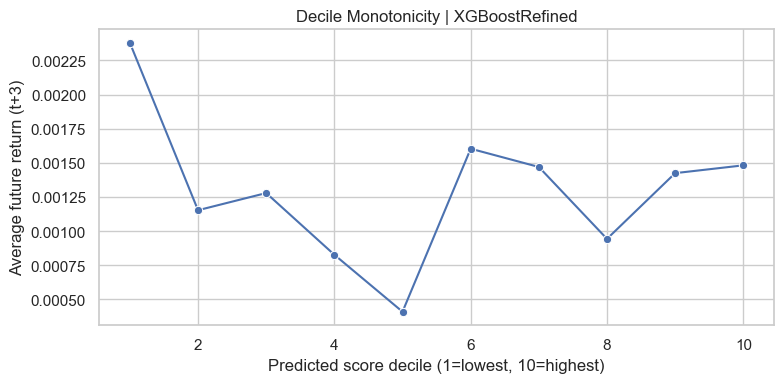

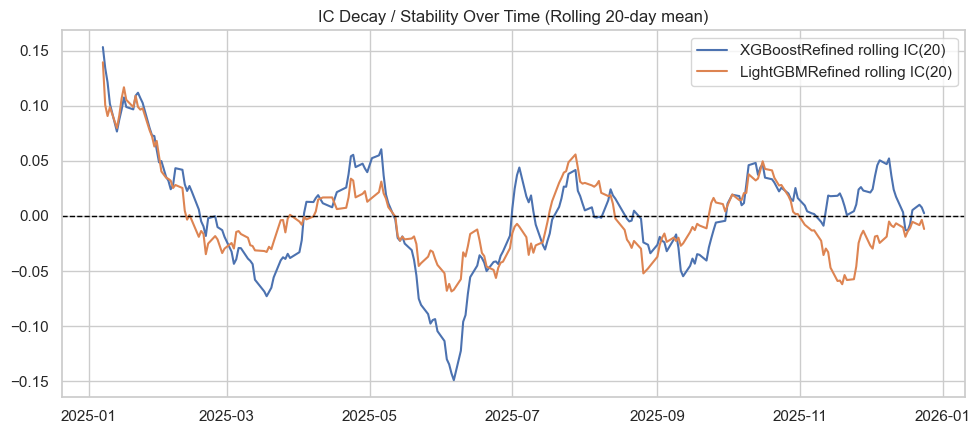

In [4]:
# STEP 8: IC evaluation (daily IC, mean, std, hit rate; decay; by regime).
ic_summary_rows = []
ic_time_store: Dict[str, pd.DataFrame] = {}

for model_name in pred_store.keys():
    pred_col = f'pred_{model_name}'

    daily_ic_raw = compute_daily_ic(test_df, pred_col, 'target_future_return_t3')
    daily_ic_resid = compute_daily_ic(test_df, pred_col, 'residual_return_t3')

    m_raw = float(daily_ic_raw['IC'].mean()) if len(daily_ic_raw) else np.nan
    s_raw = float(daily_ic_raw['IC'].std(ddof=1)) if len(daily_ic_raw) > 1 else np.nan
    h_raw = float((daily_ic_raw['IC'] > 0).mean()) if len(daily_ic_raw) else np.nan

    m_res = float(daily_ic_resid['IC'].mean()) if len(daily_ic_resid) else np.nan

    ic_summary_rows.append({
        'Model': model_name,
        'Mean_IC_raw': m_raw,
        'IC_Std_raw': s_raw,
        'IC_Hit_Rate_raw': h_raw,
        'Mean_IC_residual_target': m_res,
    })

    daily_ic_raw = daily_ic_raw.sort_values('Date').reset_index(drop=True)
    daily_ic_raw['IC_rolling_20'] = daily_ic_raw['IC'].rolling(20, min_periods=5).mean()
    daily_ic_raw['Model'] = model_name
    ic_time_store[model_name] = daily_ic_raw

ic_summary_df = pd.DataFrame(ic_summary_rows).sort_values('Mean_IC_raw', ascending=False).reset_index(drop=True)
display(ic_summary_df.round(4))

best_model = str(ic_summary_df.iloc[0]['Model'])
best_pred_col = f'pred_{best_model}'

# Regime assignment for IC-by-regime.
q1 = float(model_df.loc[train_mask, 'Volatility_20'].quantile(1/3))
q2 = float(model_df.loc[train_mask, 'Volatility_20'].quantile(2/3))
def to_regime(v: float) -> str:
    if v <= q1:
        return 'LOW'
    if v <= q2:
        return 'MEDIUM'
    return 'HIGH'

test_df['Regime'] = test_df['Volatility_20'].map(to_regime)

regime_ic_rows = []
for reg in ['LOW', 'MEDIUM', 'HIGH']:
    sub = test_df[test_df['Regime'] == reg].copy()
    ic_reg = compute_daily_ic(sub, best_pred_col, 'target_future_return_t3')
    regime_ic_rows.append({
        'Regime': reg,
        'Mean_IC_raw': float(ic_reg['IC'].mean()) if len(ic_reg) else np.nan,
        'IC_Std_raw': float(ic_reg['IC'].std(ddof=1)) if len(ic_reg) > 1 else np.nan,
        'IC_Hit_Rate_raw': float((ic_reg['IC'] > 0).mean()) if len(ic_reg) else np.nan,
    })
regime_ic_df = pd.DataFrame(regime_ic_rows)
display(regime_ic_df.round(4))

# STEP 9: Decile monotonicity test.
mono_df = test_df[['Date', 'Ticker', 'target_future_return_t3', best_pred_col]].copy()
mono_df['pred_rank'] = mono_df.groupby('Date')[best_pred_col].rank(method='first')
mono_df['decile'] = mono_df.groupby('Date')['pred_rank'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1 if x.nunique() >= 10 else np.nan
)
decile_ret = mono_df.dropna(subset=['decile']).groupby('decile', as_index=False)['target_future_return_t3'].mean()
decile_ret['decile'] = decile_ret['decile'].astype(int)
decile_spearman, _ = spearmanr(decile_ret['decile'], decile_ret['target_future_return_t3'])
display(decile_ret.round(5))
print(f'Decile monotonicity Spearman(decile, avg_return): {float(decile_spearman):.4f}')

plt.figure(figsize=(8, 4))
sns.lineplot(data=decile_ret, x='decile', y='target_future_return_t3', marker='o')
plt.title(f'Decile Monotonicity | {best_model}')
plt.xlabel('Predicted score decile (1=lowest, 10=highest)')
plt.ylabel('Average future return (t+3)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
for m, ic_t in ic_time_store.items():
    if len(ic_t):
        plt.plot(ic_t['Date'], ic_t['IC_rolling_20'], label=f'{m} rolling IC(20)')
plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
plt.title('IC Decay / Stability Over Time (Rolling 20-day mean)')
plt.legend()
plt.tight_layout()
plt.show()


,Metric,Step-28,Step-29
0,Mean IC,0.0183,-0.0017
1,IC std,0.1396,0.1322
2,Sharpe,2.6280,-0.9826
3,Drawdown,-0.1300,-0.4244


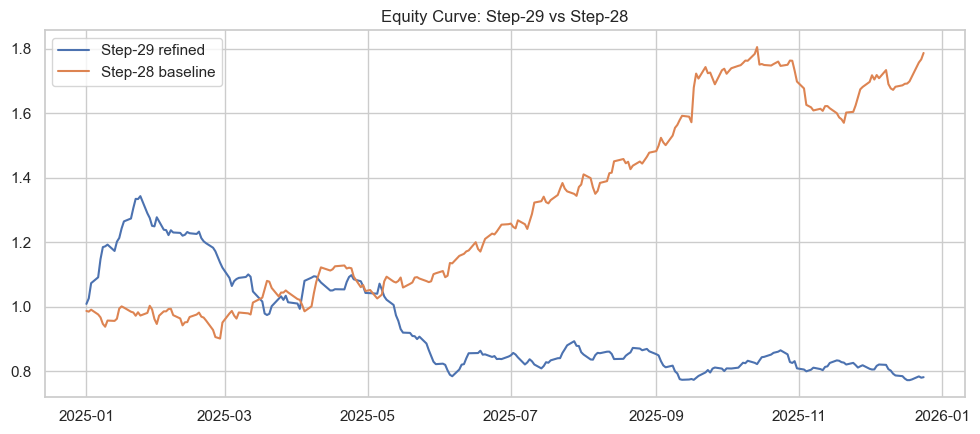

,feature,importance
0,realized_vol_5_cs_z,0.101990
1,Volatility_50_cs_z,0.101279
2,Volatility_20_cs_z,0.095575
3,realized_vol_20_cs_z,0.087650
4,volatility_breakout_interaction_lag2_cs_rank,0.085074
5,volatility_breakout_interaction_lag2_cs_z,0.083884
6,volatility_breakout_interaction_lag1_cs_rank,0.081807
7,volatility_breakout_interaction_lag1_cs_z,0.081355
8,Volatility_50_cs_rank,0.075418
9,realized_vol_20_cs_rank,0.070332


IC mean (Step-29): -0.0017
IC stability/std (Step-29): 0.1322
Sharpe (Step-29): -0.9826
Saved refined alpha results: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\refined_alpha_results.parquet


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_5280\1281974038.py:110: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  save_df = pd.concat([


In [5]:
# STEP 10: Backtest (top 10 long / bottom 10 short, equal weight)
portfolio_trades, daily_pnl = long_short_top_bottom(test_df, best_pred_col, 'target_future_return_t3', top_n=TOP_N)
equity = (1.0 + daily_pnl).cumprod()

step29_total = float(equity.iloc[-1] - 1.0)
step29_sharpe = float(sharpe_ratio(daily_pnl))
step29_mdd = float(max_drawdown(equity))

# STEP 11: Comparison vs Step-28
if STEP28_PATH.exists():
    step28 = pd.read_parquet(STEP28_PATH).copy()
    step28['Date'] = pd.to_datetime(step28['Date'])

    step28_ic_mean = float(step28['ic_mean_selected'].iloc[0]) if 'ic_mean_selected' in step28.columns else np.nan
    step28_ic_std = float(step28['ic_std_selected'].iloc[0]) if 'ic_std_selected' in step28.columns else np.nan
    step28_sharpe = float(step28['sharpe_selected'].iloc[0]) if 'sharpe_selected' in step28.columns else np.nan

    step28_daily = step28[['Date', 'daily_portfolio_return']].drop_duplicates('Date').set_index('Date')['daily_portfolio_return'].sort_index()
    step28_mdd = float(max_drawdown((1.0 + step28_daily).cumprod())) if len(step28_daily) else np.nan
else:
    step28_ic_mean = 0.0183
    step28_ic_std = np.nan
    step28_sharpe = 2.6
    step28_mdd = np.nan

step29_ic_mean = float(ic_summary_df.loc[ic_summary_df['Model'] == best_model, 'Mean_IC_raw'].iloc[0])
step29_ic_std = float(ic_summary_df.loc[ic_summary_df['Model'] == best_model, 'IC_Std_raw'].iloc[0])

compare_table = pd.DataFrame([
    {'Metric': 'Mean IC', 'Step-28': step28_ic_mean, 'Step-29': step29_ic_mean},
    {'Metric': 'IC std', 'Step-28': step28_ic_std, 'Step-29': step29_ic_std},
    {'Metric': 'Sharpe', 'Step-28': step28_sharpe, 'Step-29': step29_sharpe},
    {'Metric': 'Drawdown', 'Step-28': step28_mdd, 'Step-29': step29_mdd},
])
display(compare_table.round(4))

plt.figure(figsize=(10, 4.5))
plt.plot(equity.index, equity.values, label='Step-29 refined')
if 'step28_daily' in locals() and len(step28_daily) > 0:
    plt.plot(step28_daily.index, (1.0 + step28_daily).cumprod().values, label='Step-28 baseline')
plt.title('Equity Curve: Step-29 vs Step-28')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance (include in output).
if best_model == 'LightGBMRefined' and HAS_LIGHTGBM:
    imp_values = lgbm.feature_importances_
else:
    imp_values = xgb.feature_importances_
fi_df = pd.DataFrame({'feature': model_features, 'importance': imp_values}).sort_values('importance', ascending=False).reset_index(drop=True)
display(fi_df.head(25))

# BONUS: SHAP summary (if package available).
shap_summary_df = pd.DataFrame(columns=['feature', 'mean_abs_shap'])
if HAS_SHAP:
    sample_n = min(2000, len(X_test))
    sample_x = X_test.iloc[:sample_n]
    if best_model == 'LightGBMRefined' and HAS_LIGHTGBM:
        explainer = shap.TreeExplainer(lgbm)
    else:
        explainer = shap.TreeExplainer(xgb)
    shap_vals = explainer.shap_values(sample_x)
    shap_arr = np.asarray(shap_vals)
    if shap_arr.ndim == 2:
        mean_abs = np.abs(shap_arr).mean(axis=0)
        shap_summary_df = pd.DataFrame({'feature': sample_x.columns, 'mean_abs_shap': mean_abs}).sort_values('mean_abs_shap', ascending=False)
        display(shap_summary_df.head(20))

# STEP 12: Save output parquet with predictions + IC metrics + feature importance.
daily_map = daily_pnl.to_dict()
pred_out = portfolio_trades.copy()
pred_out['daily_portfolio_return'] = pred_out['Date'].map(daily_map)
pred_out['model_selected'] = best_model
pred_out['step29_mean_ic_raw'] = step29_ic_mean
pred_out['step29_ic_std_raw'] = step29_ic_std
pred_out['step29_sharpe'] = step29_sharpe
pred_out['step29_max_drawdown'] = step29_mdd
pred_out['record_type'] = 'prediction'

fi_out = fi_df.copy()
fi_out['record_type'] = 'feature_importance'
fi_out['Date'] = pd.NaT
fi_out['Ticker'] = np.nan
fi_out['target_future_return_t3'] = np.nan
fi_out['residual_return_t3'] = np.nan
fi_out[best_pred_col] = np.nan
fi_out['side'] = np.nan
fi_out['weight'] = np.nan
fi_out['pnl_component'] = np.nan
fi_out['daily_portfolio_return'] = np.nan
fi_out['model_selected'] = best_model
fi_out['step29_mean_ic_raw'] = step29_ic_mean
fi_out['step29_ic_std_raw'] = step29_ic_std
fi_out['step29_sharpe'] = step29_sharpe
fi_out['step29_max_drawdown'] = step29_mdd

top_fi_json = json.dumps(fi_df.head(30).to_dict(orient='records'))
pred_out['feature_importance_json_top30'] = top_fi_json
fi_out['feature_importance_json_top30'] = top_fi_json

if len(shap_summary_df) > 0:
    top_shap_json = json.dumps(shap_summary_df.head(30).to_dict(orient='records'))
else:
    top_shap_json = json.dumps([])
pred_out['shap_summary_json_top30'] = top_shap_json
fi_out['shap_summary_json_top30'] = top_shap_json

common_cols = sorted(set(pred_out.columns) | set(fi_out.columns))
save_df = pd.concat([
    pred_out.reindex(columns=common_cols),
    fi_out.reindex(columns=common_cols),
], ignore_index=True)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_df.to_parquet(OUT_PATH, index=False)

print(f'IC mean (Step-29): {step29_ic_mean:.4f}')
print(f'IC stability/std (Step-29): {step29_ic_std:.4f}')
print(f'Sharpe (Step-29): {step29_sharpe:.4f}')
print(f'Saved refined alpha results: {OUT_PATH}')
